#준비

##임포트

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
from google.colab import files
from PIL import Image
import os
from ultralytics import YOLO
import math
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


##드라이브 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 함수 정의

### 점수 계산

In [ ]:
def get_objects(label, detected_objects):
        return [obj for obj in detected_objects if obj["class_name"] == label]

def area(obj):
        return obj["width"] * obj["height"]

# 개방성

# 평가 요소: 문, 창문, 울타리, 길
def compute_openness_score(detected_objects, img_w=1280, img_h=1280):

    house = next((obj for obj in detected_objects if obj["class_name"] == "집전체"), None)
    if not house:
        return 0

    house_area = area(house)
    house_height = house["height"]
    openness = 0

    # 1. 문 점수 - 최대 50점

    # 존재하면 30점
    # 집 크기와의 비율에 따라 -20 ~ +20점 조정
    door_objs = [obj for obj in detected_objects if obj["class_name"] == "문"]
    if door_objs:
        door = door_objs[0]
        door_area = area(door)
        ratio = door_area / house_area
        door_score = 30
        if ratio < 0.02:
            door_score -= ((0.02 - ratio) / 0.02) * 20
        elif ratio > 0.04:
            door_score += ((ratio - 0.04) / 0.04) * 20
        door_score = min(50, max(30, door_score))
        openness += door_score

    # 2. 창문 점수 - 최대 30점

    # 1개 당 +10점
    # 집 크기와의 비율에 따라 창문 당 -2 ~ +2점 조정
    windows = [obj for obj in detected_objects if obj["class_name"] == "창문"]
    window_score = min(len(windows), 5) * 10  # 개당 10점, 최대 50점

    for w in windows:
        ratio = area(w) / house_area
        if ratio <= 0.005:
            window_score -= 2 * (0.005 - ratio) / 0.005
        elif ratio >= 0.015:
            window_score += 2 * (ratio - 0.015) / 0.015
    window_score = min(30, max(0, window_score))
    openness += window_score

    # 3. 울타리 점수 최대 -20점

    # 존재하면 -10점
    # 울타리의 높이에 따라 -20점까지 조정
    fence_objs = [obj for obj in detected_objects if obj["class_name"] == "울타리"]
    if fence_objs:
        fence = fence_objs[0]
        height_ratio = fence["height"] / house_height
        fence_score = -10
        if height_ratio >= 0.5:
            fence_score -= min(10, (height_ratio - 0.5) / 0.5 * 20)
        openness += fence_score

    # 4. 길 점수 - 20점

    # 존재하면 20점
    if any(obj for obj in detected_objects if obj["class_name"] == "길"):
        openness += 20

    return round(max(0, min(100, openness)), 2)

# 활력성

# 평가 요소: 태양, 나무, 꽃, 잔디, 연못
def compute_vitality_score(detected_objects, img_width=1280, img_height=1280):
    score = 0

    # 1. 태양 위치 점수 - 최대 50점

    # 그림의 중심에 있을 수록, 상단에 있을 수록 +50점까지 조정
    sun = next((obj for obj in detected_objects if obj["class_name"] == "태양"), None)
    if sun:
        center_x = sun["x_center"]
        center_y = sun["y_center"]
        center_score = 1 - abs(center_x - img_width / 2) / (img_width / 2)
        top_score = 1 - center_y / img_height
        sun_score = ((center_score + top_score) / 2) * 50
    else:
        sun_score = 0

    score += sun_score

    # 2. 자연물 개수 점수 (나무, 꽃, 잔디, 연못) - 최대 35점

    # 1개 당 5점
    natural_labels = {"나무", "꽃", "잔디", "연못"}
    nature_count = sum(1 for obj in detected_objects if obj["class_name"] in natural_labels)
    nature_score = min(nature_count * 5, 35)

    score += nature_score

    # 3. 객체 분산도 점수 - 최대 25점

    # 전체 객체가 넓게 분포할 수록 +25점까지 조정
    distributed_labels = {
        "집전체", "문", "창문", "울타리", "길",
        "태양", "굴뚝", "지붕", "연기",
        "나무", "꽃", "잔디", "연못"
    }

    centers = [
        (obj["x_center"], obj["y_center"])
        for obj in detected_objects
        if obj["class_name"] in distributed_labels
    ]

    if len(centers) >= 2:
        xs, ys = zip(*centers)
        std_x = np.std(xs) / img_width
        std_y = np.std(ys) / img_height
        spread_score = ((std_x + std_y) / 2) * 50
        spread_score = min(spread_score, 25)
    else:
        spread_score = 0

    score += spread_score

    return round(min(score, 100), 2)

# 온화성

# 평가 요소: 굴뚝, 태양, 꽃
def compute_warmth_score(detected_objects, img_width=1280, img_height=1280):
    IMG_AREA = img_width * img_height


    house_objs = get_objects("집전체", detected_objects)
    if not house_objs:
        return 0
    house_area = area(house_objs[0])

    # 1. 굴뚝 면적 점수 - 최대 30점

    # 집 크기와의 비율에 따라 0 ~ +30점 조정
    chimney_objs = get_objects("굴뚝", detected_objects)
    chimney_area = area(chimney_objs[0]) if chimney_objs else 0
    chimney_ratio = chimney_area / house_area if house_area > 0 else 0
    chimney_score = min(30, chimney_ratio * 200)

    # 2. 태양 면적 점수 - 최대 70점

    # 전체 배경 크기와의 비율에 따라 0 ~ +70점 조정
    sun_objs = get_objects("태양", detected_objects)
    sun_area = area(sun_objs[0]) if sun_objs else 0
    sun_ratio = sun_area / IMG_AREA
    sun_score = min(70, sun_ratio * 400)

    # 3. 꽃 개수 점수 - 최대 30점

    # 1개 당 5점
    flower_objs = get_objects("꽃", detected_objects)
    flower_score = min(len(flower_objs) * 5, 30)

    total = min(100, chimney_score + sun_score + flower_score)
    return round(total, 2)

# 안정성

# 평가 요소: 지붕, 집 전체, 연기,
def compute_stability_score(detected_objects, img_width=1280, img_height=1280):
    IMG_AREA = img_width * img_height

    house = get_objects("집전체", detected_objects)[0]
    house_area = area(house)
    house_cx = house["x_center"]
    house_cy = house["y_center"]

    # 1. 지붕 점수

    # 집 크기와의 비율에 따라 0 ~ +50점 조정 (면적 비율이 0.4 ~ 0.6일 때 최대)
    roof_objs = get_objects("지붕", detected_objects)
    roof_area = area(roof_objs[0]) if roof_objs else 0
    roof_ratio = roof_area / house_area if house_area > 0 else 0

    if 0.4 <= roof_ratio <= 0.6:
        roof_score_raw = 40
    elif roof_ratio < 0.4:
        roof_score_raw = max(0, 40 - ((0.4 - roof_ratio) / 0.4) * 40)
    else:
        roof_score_raw = max(0, 40 - ((roof_ratio - 0.6) / 0.4) * 40)

    roof_score = roof_score_raw * (50 / 40)

    # 2. 중심 위치 점수 (최대 30점)

    # 그림 중앙에 가까울 수록 +30점까지 조정
    dist = np.sqrt((house_cx - img_width / 2) ** 2 + (house_cy - img_height / 2) ** 2)
    max_dist = np.sqrt((img_width / 2) ** 2 + (img_height / 2) ** 2)
    center_score = max(0, 30 * (1 - dist / max_dist))

    # 3. 연기 점수 (최대 20점)

    # 연기의 면적이 그림의 5% 이내일수록 +20점까지 조정
    smoke_objs = get_objects("연기", detected_objects)
    if smoke_objs:
        smoke_area = area(smoke_objs[0])
        smoke_ratio = smoke_area / IMG_AREA
        raw_smoke_score = 0 if smoke_ratio > 0.05 else max(0, 30 * (1 - smoke_ratio / 0.05))
        smoke_score = raw_smoke_score * (20 / 30)
    else:
        smoke_score = 0

    # 4. 좌우 치우침 감점 (최대 -15점)

    # 집이 그림의 좌우로 치우쳐 있을 수록 -15점까지 조정
    x_offset = abs(house_cx - img_width / 2)
    max_offset = img_width / 2
    shift_penalty = min(15, (x_offset / max_offset) * 15)

    stability = round(min(100, roof_score + center_score + smoke_score - shift_penalty), 2)
    return stability

### 케이스 분류

In [ ]:
def classify_case(openness, vitality, warmth, stability):
    scores = {
        "O": openness,
        "V": vitality,
        "W": warmth,
        "S": stability
    }

    # 50에서 얼마나 멀리 떨어졌는지 계산
    deltas = {k: abs(v - 50) for k, v in scores.items()}

    # 우선순위: O > V > W > S
    priority = ["O", "V", "W", "S"]

    # 가장 두드러지는 두 특성 추출
    top2 = sorted(priority, key=lambda k: (-deltas[k], priority.index(k)))[:2]
    top2.sort(key=lambda k: priority.index(k))

    # 점수 기준으로 대소문자 적용
    label = "".join([k if scores[k] >= 50 else k.lower() for k in top2])
    return label

###  스크립트 출력

In [ ]:
def print_case_script(case_label):
    scripts = {
        "OV": "자기 자신에 대해 명확한 감각을 지니고 있으며, 새로운 경험과 자극에 대해 거부감이 없습니다.\n감정 표현이 자연스럽고 외부 세계와의 상호작용을 즐기는 성향이 강합니다.\n마음속 에너지가 가득 차 있어서 주변 사람에게도 활기를 불어넣는 편입니다.\n무언가를 시작할 때 주저함이 적고, 변화를 긍정적으로 받아들이는 태도를 갖고 있습니다.",
        "Ov": "새로운 생각이나 시도를 즐기는 편이지만, 에너지 자체는 조용히 내면에 머무는 타입입니다.\n자극에 개방적이지만 그것을 외부로 강하게 드러내지는 않습니다.\n혼자만의 공간에서 상상하거나 사색하는 시간을 중요하게 여기는 경향이 있습니다.\n겉으로는 조용해 보여도 마음속에 다양한 아이디어와 가능성을 품고 있습니다.",
        "oV": "자신이 아는 것과 익숙한 세계 안에서 에너지를 활발하게 쏟는 편입니다.\n새로운 방식보다는 익숙한 방식을 좋아하면서도, 활동성과 생동감은 충분히 가지고 있어요.\n주어진 환경 안에서 즐겁게 움직이며 주변을 밝게 만드는 사람이 될 수 있습니다.\n한 번 결정한 방향으로 꾸준히 밀고 나가는 추진력을 가진 타입이에요.",
        "ov": "익숙하고 안정적인 환경을 선호하면서도, 크게 에너지를 드러내지는 않는 성향입니다.\n조용한 일상을 소중히 여기고, 새로운 변화보다는 지금 가진 것을 지키는 데 집중합니다.\n혼자만의 시간이 중요하고, 타인의 기대보다는 자신의 페이스를 유지하려는 경향이 있어요.\n천천히, 신중하게 움직이며 마음이 가는 일에만 에너지를 쏟습니다.",
        "OW": "새로운 시도에 거침이 없고, 따뜻한 분위기를 자연스럽게 만들어내는 사람입니다.\n열려 있는 마음과 감성적인 따뜻함이 조화를 이루며 주변에 긍정적인 영향을 줍니다.\n사람들과의 관계에서도 부담 없이 다가가고, 감정을 섬세하게 공감해주는 편이에요.\n당신과 있으면 분위기가 부드러워지고, 뭔가 더 자유로워지는 느낌이 듭니다.",
        "Ow": "당신은 새로운 생각이나 시도에 매우 열려 있는 타입이지만, 감정 표현은 절제하는 편입니다.\n외적으로는 자유롭고 창의적이지만, 내면의 감정을 드러내는 데에는 조금 신중하죠.\n이런 조합은 독특한 매력을 만들어내며, 무심한 듯 보이지만 생각은 깊은 사람이라는 인상을 줍니다.\n사람들은 당신의 자유로운 분위기에 끌리면서도, 왠지 모르게 신비감을 느낄 수 있어요.",
        "oW": "당신은 익숙함과 안정감을 중시하면서도, 따뜻한 분위기를 잘 만들어내는 사람입니다.\n새로운 자극보다는 편안함과 정서를 소중히 여기며, 감정을 자연스럽게 표현하죠.\n차분한 성향 덕분에 주변 사람들은 당신 곁에서 안도감을 느끼곤 합니다.\n당신만의 조용한 온기로 주위에 잔잔한 긍정의 영향을 주고 있어요.",
        "ow": "당신은 지금 다소 조심스럽고 내향적인 시기를 지나고 있는지도 모르겠어요.\n새로운 것에 쉽게 마음을 열지 않으며, 감정을 표현하는 데에도 약간의 망설임이 느껴집니다.\n어쩌면 주변 환경이나 상황이 당신을 살짝 움츠러들게 만들고 있을지도요.\n하지만 그 안에서 자신만의 방식으로 세상을 받아들이고 있는 모습도 엿보여요.\n때로는 이런 차분함이 자신을 보호하는 가장 좋은 무기가 되기도 합니다.",
        "OS": "당신은 새로운 것을 받아들이는 데 거침이 없고, 동시에 내면의 균형도 잘 유지하고 있어요.\n모험을 두려워하지 않으면서도 자신만의 기준과 질서를 지키는 모습이 인상적입니다.\n이런 안정적인 개방성은 주변 사람들에게도 편안한 영향을 줍니다.\n삶의 흐름을 유연하게 받아들이면서도 중심을 잃지 않는 모습이 멋져요.",
        "Os": "당신은 새로운 것을 향한 호기심이 크고 자유로운 감성을 지니고 있어요.\n다만 가끔은 중심이 흔들리거나 일상의 안정감이 부족하다고 느낄 수도 있어요.\n스스로를 더 믿고 작은 균형을 잡아간다면, 열린 마음이 더 큰 힘이 될 거예요.\n새로움을 즐기되 자신을 보호하는 법도 함께 익혀나가면 좋겠네요.",
        "oS": "당신은 안정감 있고 차분한 성향을 가지고 있어, 주변 사람들에게 신뢰를 주는 사람이에요.\n하지만 새로운 자극이나 변화에는 조금 조심스러운 편일 수 있어요.\n익숙함 속에서 편안함을 느끼는 것도 좋지만, 가끔은 작은 시도들이 큰 즐거움이 될 수 있어요.\n천천히 문을 열어보는 연습을 해보는 것도 괜찮을 거예요.",
        "os": "당신은 지금 약간의 혼란이나 불확실한 상태에 있을 수 있어요.\n변화를 마주하는 데에도 망설임이 있고, 동시에 마음 한편에선 안정을 찾지 못하고 있을지도 몰라요.\n지금은 잠시 멈춰서 스스로를 돌아보는 시간이 필요할 때예요.\n작은 것부터 차근차근 정돈해 나간다면, 분명 균형을 되찾을 수 있을 거예요.",
        "VW": "당신은 지금 에너지 넘치고 따뜻한 마음을 함께 가진 상태예요.\n주변에 생기를 불어넣고, 사람들과 편안한 분위기를 잘 만들어내는 타입이네요.\n외부와의 상호작용은 적극적이지만 날카롭지 않고, 따뜻하고 섬세한 방식으로 이뤄집니다.\n당신의 긍정적인 기운은 주변에도 좋은 영향을 줄 수 있어요.",
        "Vw": "당신은 생동감 있고 활력이 넘치는 사람입니다.\n하고 싶은 일에 몰입하고 주변을 주도하는 능력도 갖추고 있어요.\n하지만 가끔은 속마음을 부드럽게 표현하는 데에 어려움을 느낄 수 있어요.\n에너지 속에 여유를 더한다면, 사람들과의 관계도 더욱 풍성해질 거예요.",
        "vW": "당신은 조용하고 차분하지만, 마음속에는 따뜻한 온기가 가득한 사람입니다.\n적극적으로 나서기보다는 사람들의 감정을 세심하게 읽고 배려하는 편이죠.\n당장의 활력은 부족해 보여도, 당신의 따뜻한 기운은 주변에 오래 남습니다.\n천천히 나아가더라도 그 온기는 언제나 당신의 강점이 될 거예요.",
        "vw": "지금은 에너지도, 마음의 여유도 조금 부족한 상태일 수 있어요.\n세상이 다소 버겁게 느껴지고, 사람들과의 교류도 조심스러울 수 있겠네요.\n하지만 괜찮아요, 모든 사람에겐 재충전이 필요한 시기가 있으니까요.\n스스로를 너무 몰아붙이지 말고, 작게라도 따뜻한 무언가를 곁에 두는 건 어떨까요?",
        "VS": "에너지가 넘치면서도 자신만의 중심을 잘 지키는 타입이에요.\n무언가에 몰입할 때 균형감 있게 다가가고, 주변을 흔들림 없이 이끌 수 있는 힘도 있죠.\n자기 확신과 추진력을 함께 가진 모습이 인상적이에요.\n당분간은 스스로의 흐름을 믿고 나아가도 괜찮을 것 같아요.",
        "Vs": "내면에 활기가 가득한 사람이에요. 새로운 걸 시도하려는 에너지와 호기심이 돋보여요.\n하지만 때때로 중심이 살짝 흔들리거나 감정 기복이 느껴질 수 있어요.\n움직임이 많은 만큼 잠시 멈춰서 호흡을 고르는 시간도 중요해요.\n균형을 되찾으면 지금의 활력을 훨씬 더 오래 유지할 수 있을 거예요.",
        "vS": "차분하고 안정감 있는 사람이에요. 쉽게 흔들리지 않고 중심을 잘 잡는 편이죠.\n에너지를 밖으로 드러내기보다는 내면에서 조용히 다지는 타입이에요.\n요란한 변화보다는 익숙한 흐름 속에서 힘을 얻는 모습이 보여요.\n지금처럼 묵묵하게 자신만의 리듬을 지켜나가는 것도 큰 강점이에요.",
        "vs": "요즘은 마음이 조금 흔들리거나 에너지가 잘 안 나는 시기일 수도 있어요.\n새로운 자극보다는 일단 스스로를 편하게 해주는 게 먼저일지도 몰라요.\n무리해서 뭔가를 바꾸기보다, 지금 있는 자리에서 작은 여유를 찾아보는 것도 좋아요.\n때로는 멈춰 있는 것도 나름의 흐름이라는 걸 기억해 주세요.",
        "WS": "당신은 따뜻하고 안정적인 기운을 가진 사람이에요.\n사람들에게 편안함을 주고, 스스로도 균형 잡힌 삶을 중요하게 여기는 편이에요.\n급변하는 상황 속에서도 중심을 지키며 조용한 힘을 발휘하는 스타일이에요.\n이런 부드러운 안정감은 주변에도 긍정적인 영향을 줄 거예요.",
        "Ws": "당신은 따뜻한 감성을 지녔지만, 마음속은 조금 불안정할 수 있어요.\n주변에 온기를 주지만, 내면에서는 뭔가 잡히지 않는 흐름이 느껴질지도 몰라요.\n균형을 잡기 위해 가끔은 스스로를 돌보는 시간도 필요해요.\n감성은 당신의 장점이지만, 안정감도 함께 챙기면 더 멋질 거예요.",
        "wS": "겉으로는 차분하고 안정적인 모습이지만, 따뜻한 감정은 조금 덜 드러나는 편이에요.\n사람들과 적당한 거리를 유지하면서도 자기 자리를 잘 지키는 타입일 수 있어요.\n감정을 표현하는 연습을 조금 더 해보면, 관계 속에서도 안정감을 더 느낄 수 있을 거예요.\n당신만의 균형은 이미 잘 갖춰져 있으니, 이제는 조금 더 마음을 열어보는 것도 좋겠어요.",
        "ws": "요즘 마음이 조금 불안정하거나 외부 자극에 민감하게 반응할 수 있어요.\n감정을 표현하는 데 익숙하지 않고, 스스로도 중심을 잡기 어려운 시기일 수 있어요.\n하지만 이 또한 지나가는 흐름이니, 당장 무언가를 바꾸려 하기보단 잠시 쉬어가는 것도 방법이에요.\n내면의 온기를 되찾기 위한 작은 시도들로, 다시 균형을 찾을 수 있을 거예요."
    }

    print(scripts.get(case_label, "❗ 알 수 없는 case입니다."))

#심리검사

##이미지 업로드

In [ ]:
uploaded = files.upload()

# 업로드된 이미지의 파일명 얻기
img_path = list(uploaded.keys())[0]
print("업로드된 파일:", img_path)

# 이미지 열어서 확인 (선택)
img = Image.open(img_path)
img.show()

Saving 짱구.jpg to 짱구.jpg
업로드된 파일: 짱구.jpg


## 탐지


image 1/1 /content/짱구.jpg: 608x640 1 집전체, 1 지붕, 1453.1ms
Speed: 3.5ms preprocess, 1453.1ms inference, 1.3ms postprocess per image at shape (1, 3, 608, 640)


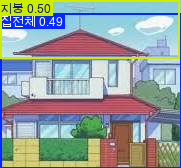

탐지된 클래스: ['지붕', '집전체']


In [ ]:
model = YOLO("/content/drive/MyDrive/2조/yolov8s/weights/best.pt")

# YOLO로 탐지
results = model(img_path)

# 탐지 결과 시각화
results[0].show()

# 탐지된 클래스 확인
detected_classes = [model.names[int(cls)] for cls in results[0].boxes.cls]
print("탐지된 클래스:", detected_classes)

#####디버깅용 로그

In [ ]:
boxes = results[0].boxes

detected_objects = []

for cls, conf, box in zip(boxes.cls, boxes.conf, boxes.xywh):
    obj = {
        "class_id": int(cls),
        "class_name": model.names[int(cls)],
        "confidence": float(conf),
        "x_center": float(box[0]),
        "y_center": float(box[1]),
        "width": float(box[2]),
        "height": float(box[3]),
    }
    detected_objects.append(obj)


openness = compute_openness_score(detected_objects)
vitality = compute_vitality_score(detected_objects)
warmth = compute_warmth_score(detected_objects)
stability = compute_stability_score(detected_objects)

print("개방성", openness)
print("활력성", vitality)
print("온화성", warmth)
print("안정성", stability)

print("\n\n")

case_label = classify_case(openness, vitality, warmth, stability)
print("이 사용자는 case:", case_label)

print("\n\n")

print_case_script(case_label)

개방성 0
활력성 0.6
온화성 0.0
안정성 38.61



이 사용자는 case: ow



당신은 지금 다소 조심스럽고 내향적인 시기를 지나고 있는지도 모르겠어요.
새로운 것에 쉽게 마음을 열지 않으며, 감정을 표현하는 데에도 약간의 망설임이 느껴집니다.
어쩌면 주변 환경이나 상황이 당신을 살짝 움츠러들게 만들고 있을지도요.
하지만 그 안에서 자신만의 방식으로 세상을 받아들이고 있는 모습도 엿보여요.
때로는 이런 차분함이 자신을 보호하는 가장 좋은 무기가 되기도 합니다.


## 결과 출력

In [ ]:
# 탐지 결과 구조화
boxes = results[0].boxes

detected_objects = []

for cls, conf, box in zip(boxes.cls, boxes.conf, boxes.xywh):
    obj = {
        "class_id": int(cls),
        "class_name": model.names[int(cls)],
        "confidence": float(conf),
        "x_center": float(box[0]),
        "y_center": float(box[1]),
        "width": float(box[2]),
        "height": float(box[3]),
    }
    detected_objects.append(obj)

# 점수 계산
openness = compute_openness_score(detected_objects)
vitality = compute_vitality_score(detected_objects)
warmth = compute_warmth_score(detected_objects)
stability = compute_stability_score(detected_objects)


# 케이스 분류
case_label = classify_case(openness, vitality, warmth, stability)


# 결과 출력
print_case_script(case_label)

지금은 에너지도, 마음의 여유도 조금 부족한 상태일 수 있어요.
세상이 다소 버겁게 느껴지고, 사람들과의 교류도 조심스러울 수 있겠네요.
하지만 괜찮아요, 모든 사람에겐 재충전이 필요한 시기가 있으니까요.
스스로를 너무 몰아붙이지 말고, 작게라도 따뜻한 무언가를 곁에 두는 건 어떨까요?
